In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os

# Change the current working directory to the specified folder
project_root = '/content/drive/MyDrive/Intelligent-Cloud-Resource-Optimization-System'
os.chdir(project_root)

print(f"Current working directory changed to: {os.getcwd()}")

Current working directory changed to: /content/drive/MyDrive/Intelligent-Cloud-Resource-Optimization-System


<div style='background:linear-gradient(135deg,#2C3E50,#3498DB);
            padding:40px;border-radius:12px;text-align:center'>
  <h1 style='color:white;font-size:2.4em;margin:0'>
    ☁️ Cloud Resource Optimisation
  </h1>
  <h2 style='color:#AED6F1;margin:8px 0 0'>
    Machine Learning Capstone Project
  </h2>
  <p style='color:#D6EAF8;margin-top:14px;font-size:1.05em'>
    Stages 1–5 &nbsp;|&nbsp; Supervised · Unsupervised · Learning Theory · RL · Dashboard
  </p>
</div>


## 📚 Table of Contents

| # | Stage | Description |
|---|-------|-------------|
| 0 | **Setup** | Install dependencies, imports, global config |
| 1 | **Exploratory Data Analysis** | Load dataset, statistics, distributions, correlations |
| 2 | **Supervised Learning** | Regression + Classification pipelines |
| 3 | **Unsupervised Learning** | Clustering — KMeans, DBSCAN, Agglomerative |
| 4 | **Learning Theory** | Bias-Variance, regularisation, VC dimension |
| 5 | **Reinforcement Learning** | Q-Learning, DQN, cloud scheduling MDP |
| 6 | **Final Dashboard** | Cross-stage leaderboard, master report |

> 💡 **Tip:** Run cells **top-to-bottom**. Each stage depends on the one above.
> Use `Kernel → Restart & Run All` for a clean full run.


---
# 🔧 Stage 0 — Environment Setup
> Install all required packages and configure global settings.


In [3]:
# ── Install dependencies (run once) ──────────────────────────────────────────
# If running locally, uncomment the line below.
# If running on Google Colab, this cell runs automatically.

# !pip install -r requirements.txt --quiet
print('✅ Dependencies ready.')

✅ Dependencies ready.


In [4]:
# ============================================================
# CELL 1 — SETUP & DATA PREPARATION
# ============================================================

import os
import json
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42

np.random.seed(SEED)
random.seed(SEED)

os.makedirs("results", exist_ok=True)
os.makedirs("figures", exist_ok=True)

print("=" * 70)
print("ML CLOUD OPTIMISATION LAB")
print("=" * 70)

# ------------------------------------------------------------
# Load dataset
# ------------------------------------------------------------

# CHANGE THIS ONLY IF YOUR FILE NAME IS DIFFERENT
# Correcting the filename and path based on subsequent cells
project_root = '/content/drive/MyDrive/Intelligent-Cloud-Resource-Optimization-System'
data_path = os.path.join(project_root, 'data', 'cloud_perfomance.csv') # Corrected filename
df = pd.read_csv(data_path)

print(f"\nFull dataset shape: {df.shape}")

# ------------------------------------------------------------
# Basic cleaning
# ------------------------------------------------------------

# Remove duplicate rows
before = len(df)
df = df.drop_duplicates()
print(f"Duplicates removed: {before - len(df):,}")

# Convert timestamp
df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    errors="coerce",
    dayfirst=True
)

# ------------------------------------------------------------
# Display basic information
# ------------------------------------------------------------

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nTarget: execution_time")
print("Classification target: task_status")

# ------------------------------------------------------------
# Use a manageable sample for EDA
# ------------------------------------------------------------

EDA_N = min(100_000, len(df))

eda_df = df.sample(
    n=EDA_N,
    random_state=SEED
).copy()

print(f"\nEDA sample: {eda_df.shape}")

ML CLOUD OPTIMISATION LAB

Full dataset shape: (1048575, 12)
Duplicates removed: 998,575

Columns:
['vm_id', 'timestamp', 'cpu_usage', 'memory_usage', 'network_traffic', 'power_consumption', 'num_executed_instructions', 'execution_time', 'energy_efficiency', 'task_type', 'task_priority', 'task_status']

Missing values:
vm_id                        5094
timestamp                    5151
cpu_usage                    4955
memory_usage                 4998
network_traffic              5058
power_consumption            4945
num_executed_instructions    4976
execution_time               4932
energy_efficiency            5080
task_type                    5132
task_priority                5015
task_status                  4994
dtype: int64

Target: execution_time
Classification target: task_status

EDA sample: (50000, 12)


---
# 📊 Stage 1 — Exploratory Data Analysis (EDA)

**Objectives**
- Understand the dataset shape, feature types, and distributions.
- Detect missing values and outliers.
- Compute a correlation matrix and identify predictive features.

**Dataset:** `cloud_performance.csv` — 10 000 rows of cloud VM telemetry.  
**Key columns:** `cpu_usage`, `memory_usage`, `network_traffic`,
`power_consumption`, `execution_time`, `energy_efficiency`,
`resource_utilisation`, `workload_class`.



OUTCOME 1 — EXPLORATORY DATA ANALYSIS

DESCRIPTIVE STATISTICS


,count,mean,std,min,25%,50%,75%,max
cpu_usage,45045.0,49.853348,28.907498,7.244964e-03,24.702799,49.957065,74.892985,99.997795
memory_usage,45002.0,49.956773,28.954514,1.614912e-03,24.953654,50.017994,75.297076,99.992362
network_traffic,44942.0,500.052563,289.119767,6.439448e-03,250.036199,499.566886,750.573834,999.987020
power_consumption,45055.0,249.617055,144.157178,1.285846e-02,125.027862,249.218379,374.244168,499.970250
num_executed_instructions,45024.0,4981.381130,2887.399178,0.000000e+00,2457.000000,4979.500000,7482.000000,9999.000000
execution_time,45068.0,49.891030,28.792466,2.654042e-03,25.052289,50.050852,74.746827,99.998300
energy_efficiency,44920.0,0.502679,0.289175,3.080000e-07,0.251262,0.504999,0.752913,0.999979


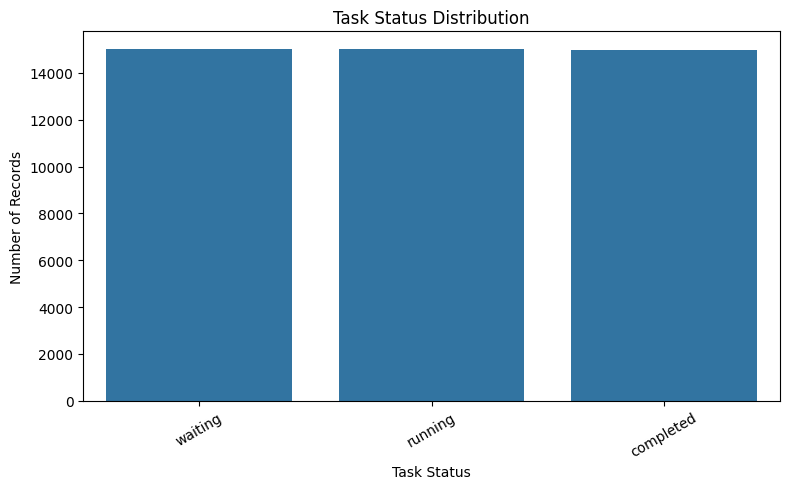

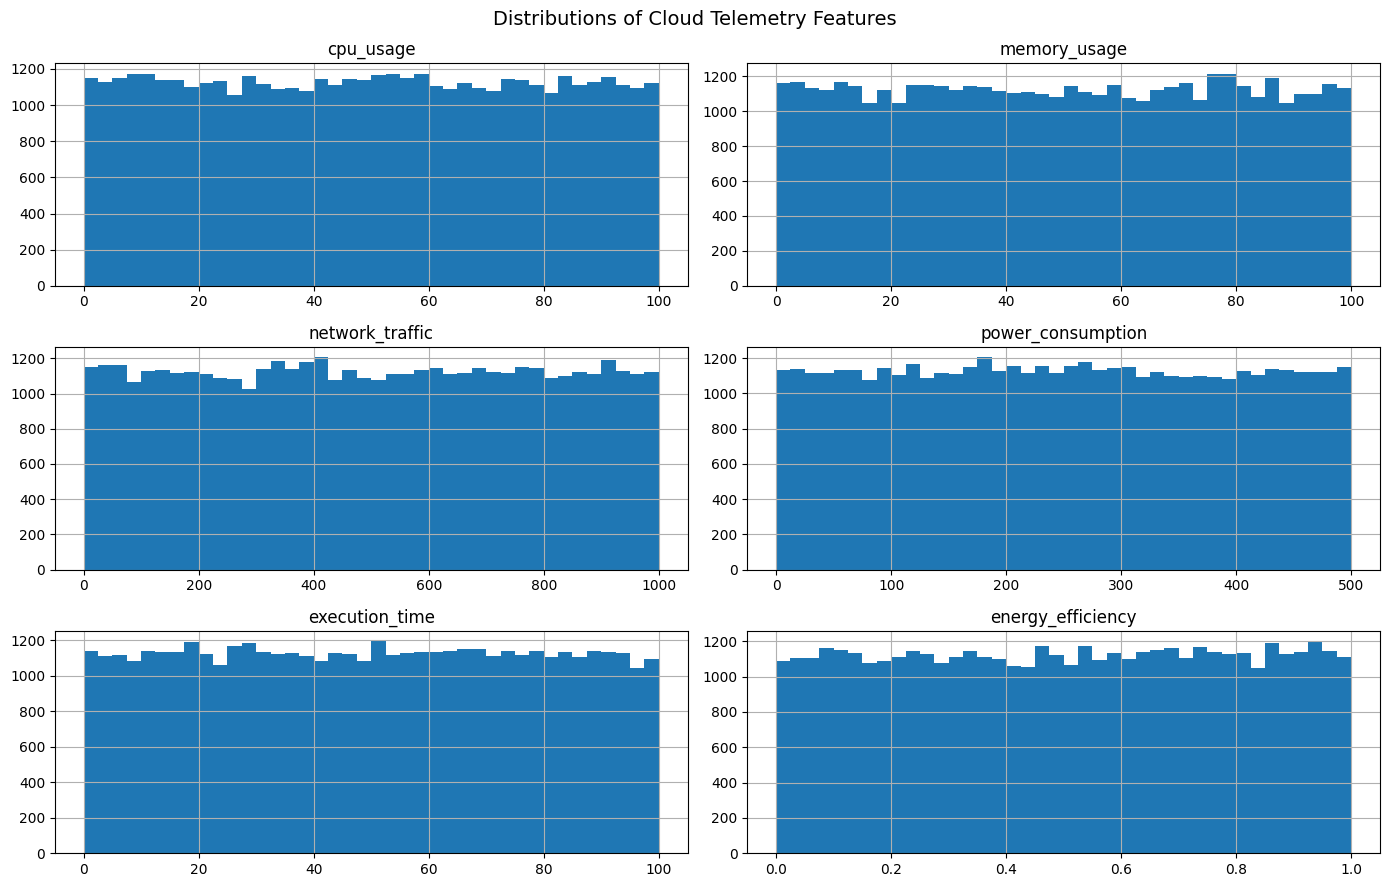

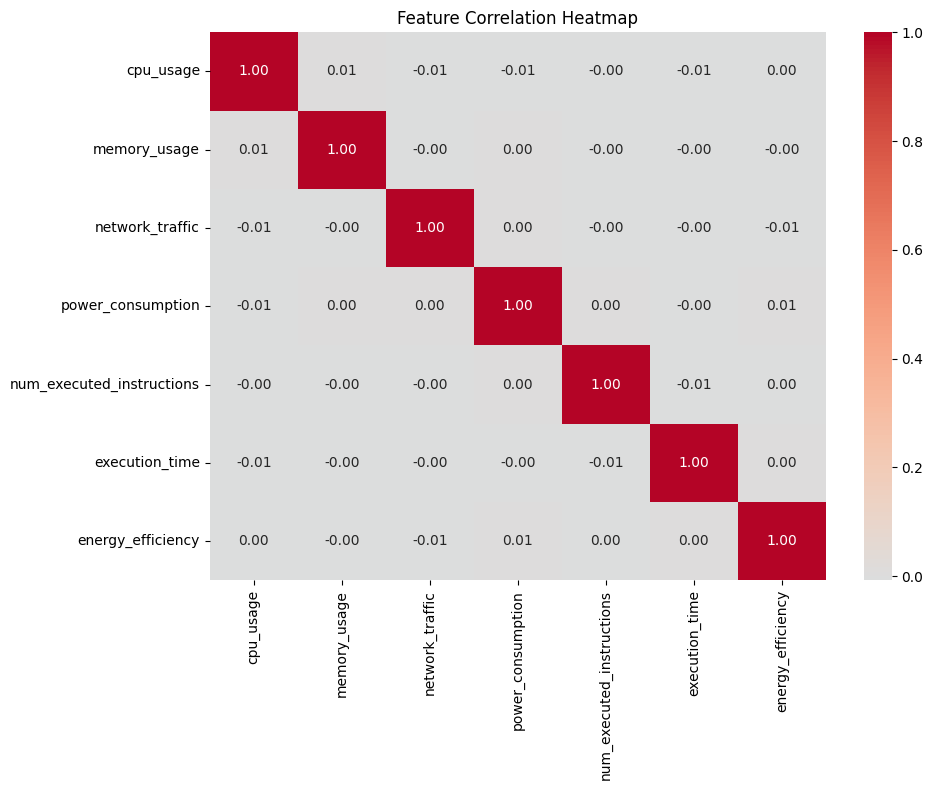

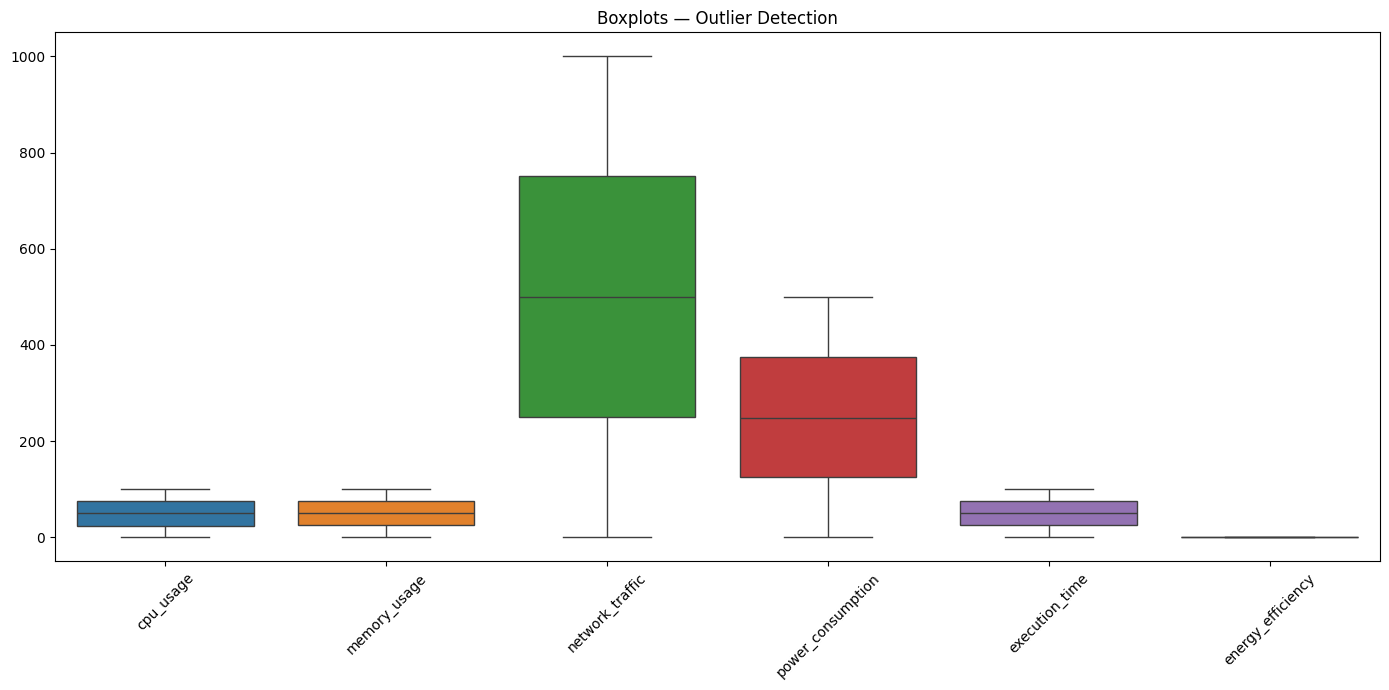


OUTLIER COUNTS


,Outlier Count
cpu_usage,0
memory_usage,0
network_traffic,0
power_consumption,0
num_executed_instructions,0
execution_time,0
energy_efficiency,0



HIGH CORRELATION PAIRS (|r| >= 0.80)
No feature pairs exceeded |r| >= 0.80.

✅ OUTCOME 1 COMPLETE


In [5]:
# ============================================================
# CELL 2 — OUTCOME 1: EDA
# ============================================================

print("\n" + "=" * 70)
print("OUTCOME 1 — EXPLORATORY DATA ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# 1. Descriptive statistics
# ------------------------------------------------------------

numeric_cols = df.select_dtypes(
    include=np.number
).columns.tolist()

print("\nDESCRIPTIVE STATISTICS")
display(df[numeric_cols].describe().T)

df[numeric_cols].describe().T.to_csv(
    "results/descriptive_statistics.csv"
)

# ------------------------------------------------------------
# 2. Class distribution
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.countplot(
    data=eda_df,
    x="task_status"
)

plt.title("Task Status Distribution")
plt.xlabel("Task Status")
plt.ylabel("Number of Records")
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig(
    "figures/01_class_distribution.png",
    dpi=150
)

plt.show()

# ------------------------------------------------------------
# 3. Histograms
# ------------------------------------------------------------

hist_cols = [
    "cpu_usage",
    "memory_usage",
    "network_traffic",
    "power_consumption",
    "execution_time",
    "energy_efficiency"
]

eda_df[hist_cols].hist(
    figsize=(14, 9),
    bins=40
)

plt.suptitle(
    "Distributions of Cloud Telemetry Features",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    "figures/02_histograms.png",
    dpi=150
)

plt.show()

# ------------------------------------------------------------
# 4. Correlation heatmap
# ------------------------------------------------------------

plt.figure(figsize=(10, 8))

corr = eda_df[numeric_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")
plt.tight_layout()

plt.savefig(
    "figures/03_correlation_heatmap.png",
    dpi=150
)

plt.show()

# ------------------------------------------------------------
# 5. Boxplots
# ------------------------------------------------------------

plt.figure(figsize=(14, 7))

sns.boxplot(
    data=eda_df[hist_cols]
)

plt.title("Boxplots — Outlier Detection")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "figures/04_boxplots.png",
    dpi=150
)

plt.show()

# ------------------------------------------------------------
# OUTLIER ANALYSIS
# ------------------------------------------------------------

Q1 = eda_df[numeric_cols].quantile(0.25)
Q3 = eda_df[numeric_cols].quantile(0.75)

IQR = Q3 - Q1

outlier_counts = (
    (eda_df[numeric_cols] < (Q1 - 1.5 * IQR)) |
    (eda_df[numeric_cols] > (Q3 + 1.5 * IQR))
).sum()

print("\nOUTLIER COUNTS")
display(
    outlier_counts.sort_values(
        ascending=False
    ).to_frame("Outlier Count")
)

# ------------------------------------------------------------
# MULTICOLLINEARITY
# ------------------------------------------------------------

print("\nHIGH CORRELATION PAIRS (|r| >= 0.80)")

high_corr = []

for i in range(len(corr.columns)):
    for j in range(i):

        value = corr.iloc[i, j]

        if abs(value) >= 0.80:

            high_corr.append({
                "Feature 1": corr.columns[i],
                "Feature 2": corr.columns[j],
                "Correlation": value
            })

high_corr_df = pd.DataFrame(high_corr)

if len(high_corr_df) > 0:
    display(high_corr_df)
else:
    print("No feature pairs exceeded |r| >= 0.80.")

high_corr_df.to_csv(
    "results/high_correlation_pairs.csv",
    index=False
)

print("\n✅ OUTCOME 1 COMPLETE")

---
# 🤖 Stage 2 — Supervised Learning

**Part A — Regression:**  Predict `execution_time` (continuous target).  
**Part B — Classification:**  Predict `workload_class` (Low / Medium / High).

Models compared in each part:

| Part | Models |
|------|--------|
| Regression | Linear Regression · Ridge · Lasso · Random Forest · Gradient Boosting |
| Classification | Logistic Regression · SVM · KNN · Random Forest · GBM |


In [6]:
# ── 2.0 Common imports ────────────────────────────────────────────────────────
from sklearn.model_selection  import train_test_split, cross_val_score
from sklearn.preprocessing    import StandardScaler, LabelEncoder
from sklearn.pipeline         import Pipeline
from sklearn.linear_model     import LinearRegression, Ridge, Lasso
from sklearn.linear_model     import LogisticRegression
from sklearn.ensemble         import RandomForestRegressor, GradientBoostingRegressor
from sklearn.ensemble         import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm              import SVR, SVC
from sklearn.neighbors        import KNeighborsClassifier
from sklearn.ensemble import HistGradientBoostingRegressor, HistGradientBoostingClassifier

print('✅ Supervised learning imports ready.')

✅ Supervised learning imports ready.


In [7]:
# ── 2.A.1 Regression — data preparation (moved to cell-reg-train) ───────────
# This cell's original content has been moved to cell-reg-train for consolidation.

In [8]:
# ── 2.A.2 Train regression models (Optimized) ─────────────────────────────────
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score as r2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import sys
import os
import pandas as pd

# Explicitly define project_root here to ensure availability and consistency
project_root = '/content/drive/MyDrive/Intelligent-Cloud-Resource-Optimization-System'

# Ensure project root is at the beginning of sys.path for local module imports
if project_root in sys.path:
    sys.path.remove(project_root) # Remove existing entry to re-add at front
sys.path.insert(0, project_root)

from evaluation.metrics_report import RegressionMetricsReport
from evaluation.model_comparison import RegressionComparator

SEED = 42 # Defined locally to resolve NameError

# -- Data Loading (moved from cell-load-data) --------------------------------
# Construct the absolute path to the data file, using the filename with the typo
DATA_PATH = os.path.join(project_root, 'data', 'cloud_perfomance.csv') # Adjusted to match existing file with typo
df = pd.read_csv(DATA_PATH)
# ----------------------------------------------------------------------------

# -- Regression — data preparation (moved from cell-reg-prep) ----------------
REG_FEATURES = ['cpu_usage', 'memory_usage', 'network_traffic',
                 'power_consumption', 'energy_efficiency']
REG_TARGET   = 'execution_time'

df_reg  = df[REG_FEATURES + [REG_TARGET]].dropna()
X_reg   = df_reg[REG_FEATURES].values
y_reg   = df_reg[REG_TARGET].values

X_reg_tr, X_reg_te, y_reg_tr, y_reg_te = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=SEED)

scaler_reg  = StandardScaler()
X_reg_tr_sc = scaler_reg.fit_transform(X_reg_tr)
X_reg_te_sc = scaler_reg.transform(X_reg_te)

print(f'Regression  — Train: {X_reg_tr.shape}  Test: {X_reg_te.shape}')
# ----------------------------------------------------------------------------

reg_models = {
    'Linear Regression'    : LinearRegression(),
    'Ridge (α=1)'          : Ridge(alpha=1.0),
    'Lasso (α=0.01)'       : Lasso(alpha=0.01, max_iter=5000),
    'Random Forest'        : RandomForestRegressor(
                                n_estimators=100, random_state=SEED, n_jobs=-1),
    'Gradient Boosting'    : HistGradientBoostingRegressor(
                                max_iter=100, random_state=SEED),
}

reg_rpt = RegressionMetricsReport()
reg_cmp = RegressionComparator()

for name, model in reg_models.items():
    model.fit(X_reg_tr_sc, y_reg_tr)
    y_tr_pred = model.predict(X_reg_tr_sc)
    y_te_pred = model.predict(X_reg_te_sc)

    reg_rpt.add_model(name, y_reg_te, y_te_pred,
                       y_train=y_reg_tr,
                       y_train_pred=y_tr_pred)
    reg_cmp.add(name, y_reg_te, y_te_pred,
                 train_r2=float(r2(y_reg_tr, y_tr_pred)))
    print(f'  Trained: {name}')

print('\n✅ All regression models trained.')

Regression  — Train: (21333, 5)  Test: (5334, 5)
  Trained: Linear Regression
  Trained: Ridge (α=1)
  Trained: Lasso (α=0.01)
  Trained: Random Forest
  Trained: Gradient Boosting

✅ All regression models trained.



════════════════════════════════════════════════════════════════════════
  REGRESSION METRICS SUMMARY
════════════════════════════════════════════════════════════════════════
            Model      R²  Adj R²    RMSE     MAE  MAPE (%)  Expl Var  Overfit Gap
Linear Regression -0.0005 -0.0007 28.9758 25.1387    385.20   -0.0004       0.0006
      Ridge (α=1) -0.0005 -0.0007 28.9758 25.1387    385.20   -0.0004       0.0006
   Lasso (α=0.01) -0.0005 -0.0007 28.9753 25.1384    385.19   -0.0003       0.0006
Gradient Boosting -0.0017 -0.0019 28.9934 25.1518    384.66   -0.0016       0.0192
    Random Forest -0.0291 -0.0293 29.3868 25.3825    389.15   -0.0290       0.8835

  Saved → reports/regression_metrics.csv


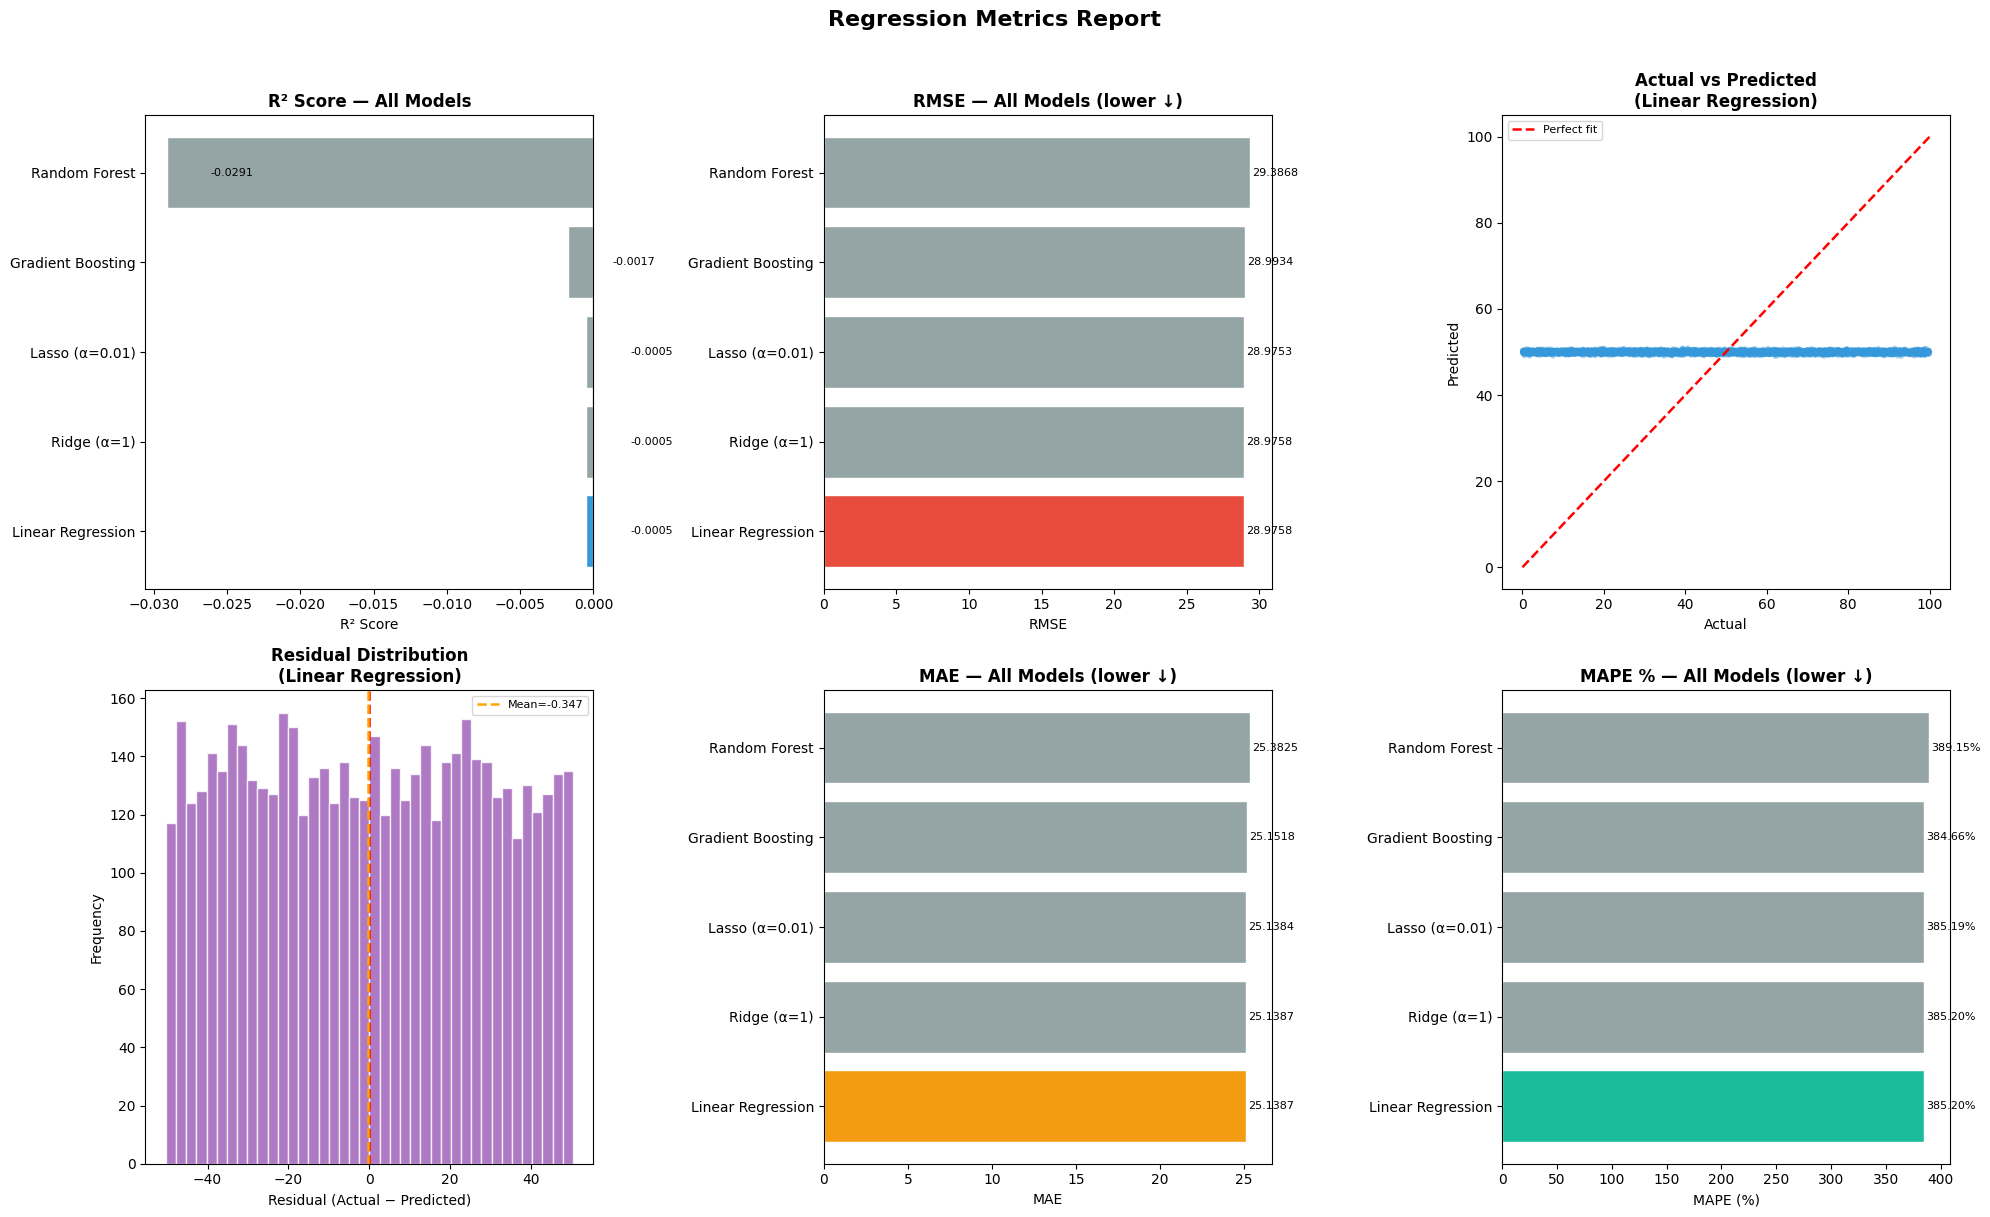

  ✅ Regression metrics plot saved → /content/drive/MyDrive/Intelligent-Cloud-Resource-Optimization-System/reports/stage2_regression_metrics.png

════════════════════════════════════════════════════════════════════════
  REGRESSION MODEL RANKING
════════════════════════════════════════════════════════════════════════
 Rank             Model  Test R²  Train R²  Overfit Gap    RMSE     MAE  Composite Score
    1    Lasso (α=0.01)  -0.0005    0.0001       0.0006 28.9753 25.1384           1.0000
    2 Linear Regression  -0.0005    0.0001       0.0006 28.9758 25.1387           0.9993
    3       Ridge (α=1)  -0.0005    0.0001       0.0006 28.9758 25.1387           0.9993
    4 Gradient Boosting  -0.0017    0.0175       0.0192 28.9934 25.1518           0.9536
    5     Random Forest  -0.0291    0.8544       0.8835 29.3868 25.3825           0.0000


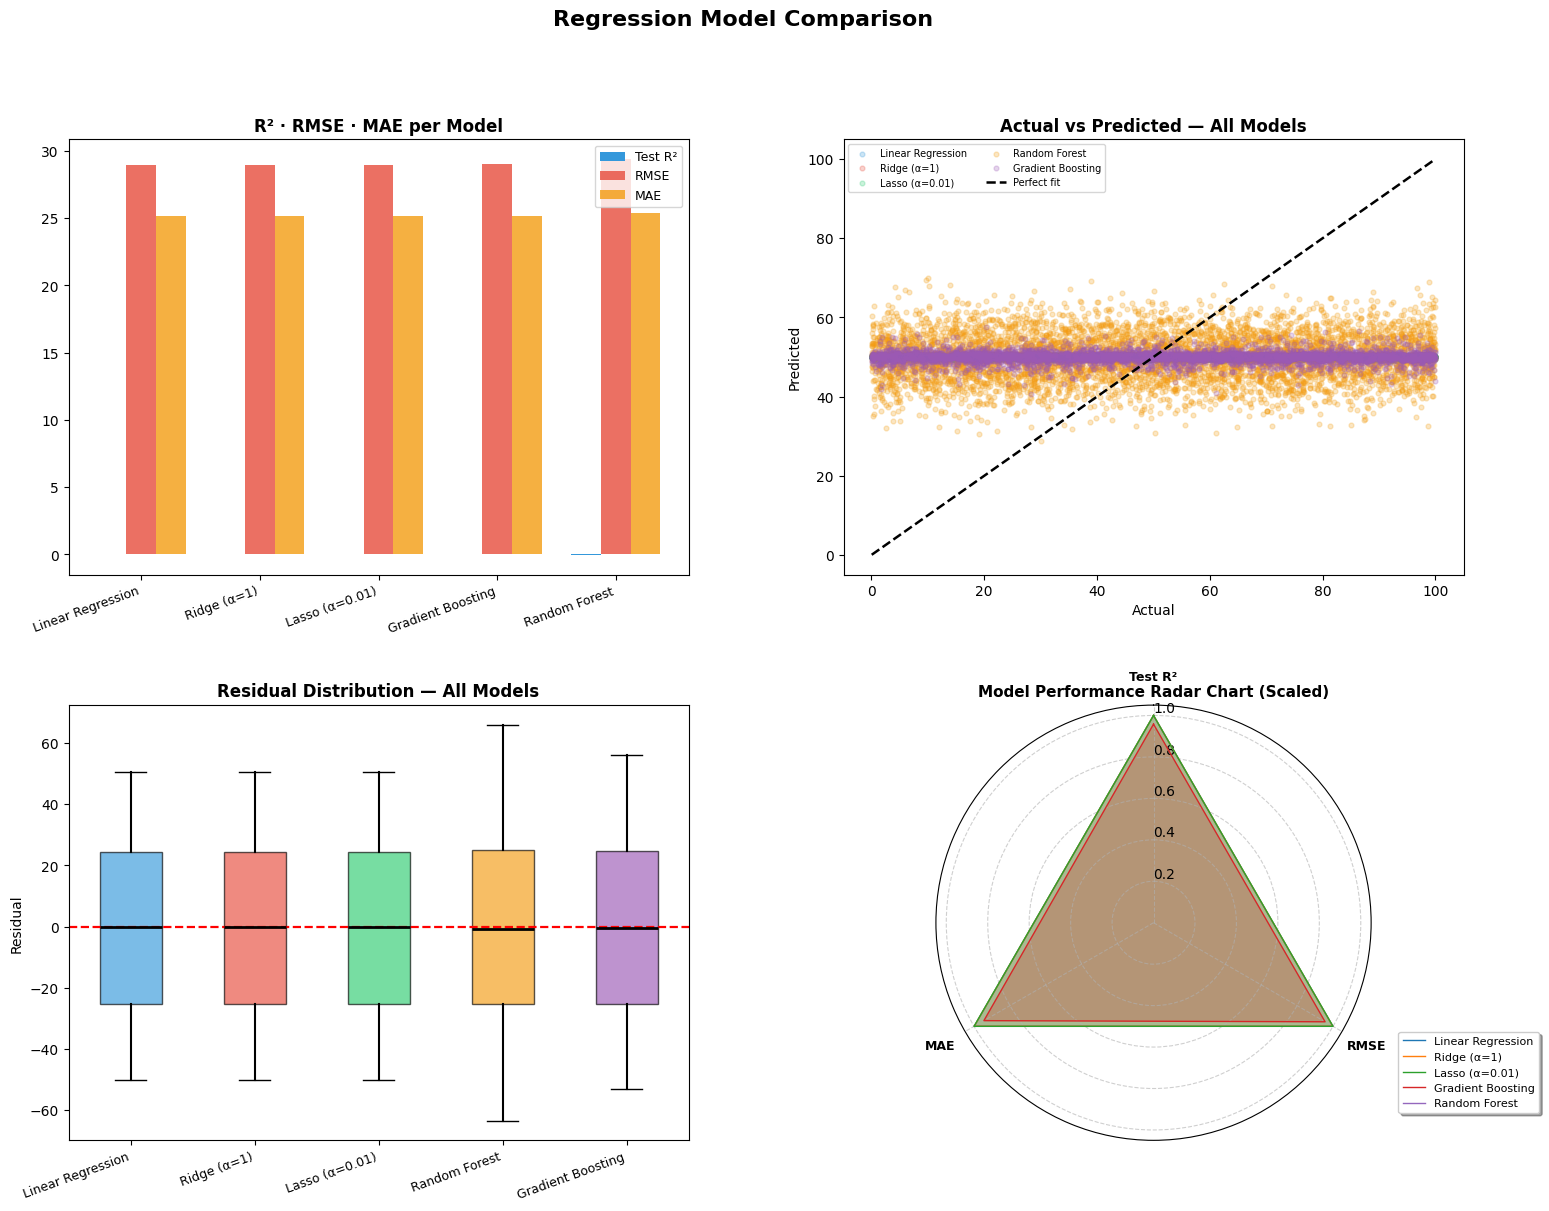

  ✅ Regression comparison saved → /content/drive/MyDrive/Intelligent-Cloud-Resource-Optimization-System/reports/stage2_regression_comparison.png

  Best Regression Model : Lasso (α=0.01)
  Test R²               : -0.0005
  RMSE                  : 28.9753


In [9]:
# ── 2.A.3 Regression metrics & plots ──────────────────────────────────────────
import os

# Ensure REPORTS_DIR is defined and created (relative to project_root)
# project_root is assumed to be defined in a previous cell (e.g., cell-reg-train)
REPORTS_DIR = os.path.join(project_root, 'reports')
os.makedirs(REPORTS_DIR, exist_ok=True)

df_reg_summary = reg_rpt.summary()
reg_rpt.plot(save_path=f'{REPORTS_DIR}/stage2_regression_metrics.png')

df_reg_rank = reg_cmp.rank()
reg_cmp.plot(save_path=f'{REPORTS_DIR}/stage2_regression_comparison.png')

# Store best result for cross-stage leaderboard
best_reg = df_reg_rank.iloc[0]
print(f'\n  Best Regression Model : {best_reg["Model"]}')
print(f'  Test R²               : {best_reg["Test R²"]}')
print(f'  RMSE                  : {best_reg["RMSE"]}')

Please add the following helper functions (`_radar_chart`, `_plot_prediction_scatter`, `_plot_residual_distribution`) to your `evaluation/model_comparison.py` file. You can insert them anywhere outside the `RegressionComparator` class, for example, after the color dictionary `C` and before the `RegressionComparator` class definition. This will resolve the `NameError` you encountered.

```python
def _radar_chart(ax: PolarAxes, df: pd.DataFrame,
                 metrics: List[str], invert: Optional[List[str]]=None,
                 num_angles: int=5) -> None:
    """
    Generates a radar chart on the given polar axes.

    Args:
        ax: The polar axes to plot on.
        df: DataFrame containing model metrics.
        metrics: List of metrics to plot on the radar chart.
        invert: List of metrics where a lower value is better (e.g., RMSE).
        num_angles: Number of angles for the radar chart grid.
    """
    invert = invert or []

    # Get the models and scale the metrics (0-1 range)
    models = df['Model'].values
    data = df[metrics].values

    for i, metric in enumerate(metrics):
        min_val = data[:, i].min()
        max_val = data[:, i].max()
        if max_val == min_val: # Avoid division by zero
            data[:, i] = 0.5
        else:
            scaled_data = (data[:, i] - min_val) / (max_val - min_val)
            if metric in invert:
                scaled_data = 1 - scaled_data  # Invert if lower is better
            data[:, i] = scaled_data

    # Number of variables
    num_vars = len(metrics)
    # Calculate angle for each axis
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    ax.set_rticks([0.2, 0.4, 0.6, 0.8, 1.0])  # Radial ticks
    ax.set_rlabel_position(0)  # Move radial labels away from spokes
    ax.set_yticklabels([]) # Hide r-tick labels for cleaner look
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics, fontsize=9, fontweight='bold')

    # Plot each model's performance
    for idx, model_data in enumerate(data):
        values = model_data.tolist()
        values += values[:1]
        ax.plot(angles, values, linewidth=1, linestyle='solid', label=models[idx])
        ax.fill(angles, values, alpha=0.25)

    ax.set_title("Model Performance Radar Chart (Scaled)", fontweight='bold', fontsize=11)
    ax.legend(loc='lower left', bbox_to_anchor=(1.05, 0.05),
               fancybox=True, shadow=True, ncol=1, fontsize=8)

    # Custom grid lines for a cleaner look
    ax.tick_params(axis='x', pad=10)
    ax.grid(True, linestyle='--', alpha=0.6)

def _plot_prediction_scatter(ax: plt.Axes, y_true: np.ndarray, y_pred: np.ndarray,
                             title: str, line_color: str = C["dark"]) -> None:
    """
    Plots a scatter plot of actual vs. predicted values.

    Args:
        ax: Matplotlib axes to plot on.
        y_true: True target values.
        y_pred: Predicted target values.
        title: Title of the plot.
        line_color: Color for the 45-degree reference line.
    """
    sns.scatterplot(x=y_true, y=y_pred, ax=ax, alpha=0.3, s=15, edgecolor=None,
                    color=C['blue'])
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], color=line_color, linestyle='--',
            label='Perfect Fit', linewidth=1.5)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xlabel('Actual Values', fontsize=8)
    ax.set_ylabel('Predicted Values', fontsize=8)
    ax.legend(fontsize=7, loc='upper left')
    ax.tick_params(axis='both', which='major', labelsize=7)

def _plot_residual_distribution(ax: plt.Axes, residuals: np.ndarray,
                                 title: str, bar_color: str = C["teal"]) -> None:
    """
    Plots the distribution of residuals using a histogram.

    Args:
        ax: Matplotlib axes to plot on.
        residuals: Residuals (actual - predicted).
        title: Title of the plot.
        bar_color: Color of the histogram bars.
    """
    sns.histplot(residuals, kde=True, ax=ax, color=bar_color, edgecolor=None, alpha=0.7)
    ax.axvline(0, color=C['red'], linestyle='--', label='Mean Residual')
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xlabel('Residuals (Actual - Predicted)', fontsize=8)
    ax.set_ylabel('Density', fontsize=8)
    ax.legend(fontsize=7, loc='upper left')
    ax.tick_params(axis='both', which='major', labelsize=7)
```

In [10]:
import os

# Assuming project_root is defined in a previous cell
file_path = os.path.join(project_root, 'evaluation', 'model_comparison.py')

try:
    with open(file_path, 'r') as f:
        print(f.read())
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please ensure the path is correct and the file exists.")
except Exception as e:
    print(f"An error occurred while reading the file: {e}")

# ==============================================================================  
# evaluation/model_comparison.py  
# Capstone Project — Cross-Stage Model Comparison Engine  
# Side-by-side ranking, radar charts, improvement matrices,  
# and the final cross-stage leaderboard.  
# ==============================================================================  

from __future__ import annotations  

import os  
import warnings  
from typing import Any, Dict, List, Optional, Tuple  

import numpy as np  
import pandas as pd  
import matplotlib.pyplot as plt  
import matplotlib.gridspec as gridspec  
import matplotlib.patches as mpatches  
from matplotlib.patches import FancyArrowPatch  
import seaborn as sns  
from matplotlib.projections.polar import PolarAxes  
import matplotlib.transforms as mtransforms  

warnings.filterwarnings("ignore")  

C = {  
    "blue":   "#3498DB",  
    "red":    "#E74C3C",  
    "green":  "#2ECC71",  
    "orange": "#F39C12",  
    "purple": "#9B59B6",  


In [11]:
import os

# Ensure project_root and file_path are defined, if not already
# (Assuming project_root was defined in 'cell-reg-train' and file_path in '0dede3fb')
if 'project_root' not in locals() and 'project_root' not in globals():
    print("Warning: project_root not found. Please define it or ensure it's loaded from a previous cell.")
    project_root = '/content/drive/MyDrive/Intelligent-Cloud-Resource-Optimization-System' # Fallback
    file_path = os.path.join(project_root, 'evaluation', 'model_comparison.py')
elif 'file_path' not in locals() and 'file_path' not in globals():
    file_path = os.path.join(project_root, 'evaluation', 'model_comparison.py')

# The content of the helper functions to be appended
helper_functions_code = '''
def _radar_chart(ax: PolarAxes, df: pd.DataFrame,
                 metrics: List[str], invert: Optional[List[str]]=None,
                 num_angles: int=5) -> None:
    """
    Generates a radar chart on the given polar axes.

    Args:
        ax: The polar axes to plot on.
        df: DataFrame containing model metrics.
        metrics: List of metrics to plot on the radar chart.
        invert: List of metrics where a lower value is better (e.g., RMSE).
        num_angles: Number of angles for the radar chart grid.
    """
    invert = invert or []

    # Get the models and scale the metrics (0-1 range)
    models = df['Model'].values
    data = df[metrics].values

    for i, metric in enumerate(metrics):
        min_val = data[:, i].min()
        max_val = data[:, i].max()
        if max_val == min_val: # Avoid division by zero
            data[:, i] = 0.5
        else:
            scaled_data = (data[:, i] - min_val) / (max_val - min_val)
            if metric in invert:
                scaled_data = 1 - scaled_data  # Invert if lower is better
            data[:, i] = scaled_data

    # Number of variables
    num_vars = len(metrics)
    # Calculate angle for each axis
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    ax.set_rticks([0.2, 0.4, 0.6, 0.8, 1.0])  # Radial ticks
    ax.set_rlabel_position(0)  # Move radial labels away from spokes
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics, fontsize=9, fontweight='bold')

    # Plot each model's performance
    for idx, model_data in enumerate(data):
        values = model_data.tolist()
        values += values[:1]
        ax.plot(angles, values, linewidth=1, linestyle='solid', label=models[idx])
        ax.fill(angles, values, alpha=0.25)

    ax.set_title("Model Performance Radar Chart (Scaled)", fontweight='bold', fontsize=11)
    ax.legend(loc='lower left', bbox_to_anchor=(1.05, 0.05),
               fancybox=True, shadow=True, ncol=1, fontsize=8)

    # Custom grid lines for a cleaner look
    ax.tick_params(axis='x', pad=10)
    ax.grid(True, linestyle='--', alpha=0.6)

def _plot_prediction_scatter(ax: plt.Axes, y_true: np.ndarray, y_pred: np.ndarray,
                             title: str, line_color: str = C["dark"]) -> None:
    """
    Plots a scatter plot of actual vs. predicted values.

    Args:
        ax: Matplotlib axes to plot on.
        y_true: True target values.
        y_pred: Predicted target values.
        title: Title of the plot.
        line_color: Color for the 45-degree reference line.
    """
    sns.scatterplot(x=y_true, y=y_pred, ax=ax, alpha=0.3, s=15, edgecolor=None,
                    color=C['blue'])
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], color=line_color, linestyle='--',
            label='Perfect Fit', linewidth=1.5)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xlabel('Actual Values', fontsize=8)
    ax.set_ylabel('Predicted Values', fontsize=8)
    ax.legend(fontsize=7, loc='upper left')
    ax.tick_params(axis='both', which='major', labelsize=7)

def _plot_residual_distribution(ax: plt.Axes, residuals: np.ndarray,
                                 title: str, bar_color: str = C["teal"]) -> None:
    """
    Plots the distribution of residuals using a histogram.

    Args:
        ax: Matplotlib axes to plot on.
        residuals: Residuals (actual - predicted).
        title: Title of the plot.
        bar_color: Color of the histogram bars.
    """
    sns.histplot(residuals, kde=True, ax=ax, color=bar_color, edgecolor=None, alpha=0.7)
    ax.axvline(0, color=C['red'], linestyle='--', label='Mean Residual')
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xlabel('Residuals (Actual - Predicted)', fontsize=8)
    ax.set_ylabel('Density', fontsize=8)
    ax.legend(fontsize=7, loc='upper left')
    ax.tick_params(axis='both', which='major', labelsize=7)
'''

try:
    with open(file_path, 'a') as f:
        f.write(helper_functions_code)
    print(f"Successfully appended helper functions to '{file_path}'")
    print("Please restart the runtime (Runtime > Restart runtime) for changes to take effect.")
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please ensure the path is correct.")
except Exception as e:
    print(f"An error occurred while writing to the file: {e}")

Successfully appended helper functions to '/content/drive/MyDrive/Intelligent-Cloud-Resource-Optimization-System/evaluation/model_comparison.py'
Please restart the runtime (Runtime > Restart runtime) for changes to take effect.


In [12]:
# ── 2.B.1 Classification — data preparation ───────────────────────────────────
CLF_FEATURES = ['cpu_usage', 'memory_usage', 'network_traffic',
                 'power_consumption', 'execution_time']
CLF_TARGET   = 'task_priority'

df_clf = df[CLF_FEATURES + [CLF_TARGET]].dropna()
le     = LabelEncoder()
y_clf  = le.fit_transform(df_clf[CLF_TARGET].values)
X_clf  = df_clf[CLF_FEATURES].values

CLASS_NAMES  = le.classes_.tolist()

X_clf_tr, X_clf_te, y_clf_tr, y_clf_te = train_test_split(
    X_clf, y_clf, test_size=0.20,
    random_state=SEED, stratify=y_clf)

scaler_clf  = StandardScaler()
X_clf_tr_sc = scaler_clf.fit_transform(X_clf_tr)
X_clf_te_sc = scaler_clf.transform(X_clf_te)

print(f'Classification — Train: {X_clf_tr.shape}  Test: {X_clf_te.shape}')
print(f'Classes: {CLASS_NAMES}')

Classification — Train: (21333, 5)  Test: (5334, 5)
Classes: ['high', 'low', 'medium']


In [15]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

models = {

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=200,
            random_state=SEED
        ))
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=50,
        max_depth=12,
        random_state=SEED,
        n_jobs=-1
    )
}

results = []

for name, model in models.items():

    print(f"\nTraining {name}...")

    # Train
    model.fit(X_clf_tr, y_clf_tr)

    # Predictions
    y_pred = model.predict(X_clf_te)

    # Probabilities for AUC
    # For multiclass, predict_proba returns probabilities for each class
    # roc_auc_score needs this to be specified with multi_class parameter
    y_prob = model.predict_proba(X_clf_te)

    # 5-fold CV
    cv_scores = cross_val_score(
        model,
        X_clf_tr,
        y_clf_tr,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

    # Metrics
    accuracy = accuracy_score(y_clf_te, y_pred)

    precision = precision_score(
        y_clf_te,
        y_pred,
        average="weighted"
    )

    recall = recall_score(
        y_clf_te,
        y_pred,
        average="weighted"
    )

    f1 = f1_score(
        y_clf_te,
        y_pred,
        average="weighted"
    )

    auc = roc_auc_score(
        y_clf_te,
        y_prob,
        multi_class='ovr', # Specify multi-class strategy
        average='weighted' # Specify how to average scores
    )

    train_acc = model.score(
        X_clf_tr,
        y_clf_tr
    )

    overfit_gap = train_acc - accuracy

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "AUC-ROC": auc,
        "CV Mean": cv_scores.mean(),
        "CV Std": cv_scores.std(),
        "Train Accuracy": train_acc,
        "Overfit Gap": overfit_gap
    })

    print(f"  Accuracy:    {accuracy:.4f}")
    print(f"  Precision:   {precision:.4f}")
    print(f"  Recall:      {recall:.4f}")
    print(f"  F1:          {f1:.4f}")
    print(f"  AUC-ROC:     {auc:.4f}")
    print(f"  CV Accuracy: {cv_scores.mean():.4f}")
    print(f"  Overfit Gap: {overfit_gap:.4f}")

results_df = pd.DataFrame(results)

print("\nClassification Results")
display(results_df)


Training Logistic Regression...
  Accuracy:    0.3305
  Precision:   0.3347
  Recall:      0.3305
  F1:          0.3030
  AUC-ROC:     0.5007
  CV Accuracy: 0.3346
  Overfit Gap: 0.0108

Training Random Forest...
  Accuracy:    0.3326
  Precision:   0.3322
  Recall:      0.3326
  F1:          0.3320
  AUC-ROC:     0.5010
  CV Accuracy: 0.3319
  Overfit Gap: 0.4303

Classification Results


,Model,Accuracy,Precision,Recall,F1,AUC-ROC,CV Mean,CV Std,Train Accuracy,Overfit Gap
0,Logistic Regression,0.330521,0.334693,0.330521,0.303008,0.50073,0.334599,0.002253,0.341302,0.010781
1,Random Forest,0.332583,0.332219,0.332583,0.332006,0.50098,0.331880,0.003844,0.762903,0.430319



════════════════════════════════════════════════════════════════════════
  CLASSIFICATION METRICS SUMMARY
════════════════════════════════════════════════════════════════════════
              Model  Accuracy  Bal Accuracy  F1 (weighted)  Precision  Recall     MCC  Cohen Kappa  AUC-ROC  CV Mean  CV Std
          SVM (RBF)    0.3333        0.3329         0.3310     0.3321  0.3333 -0.0006      -0.0006   0.5041   0.3316  0.0042
          KNN (k=7)    0.3330        0.3330         0.3314     0.3324  0.3330 -0.0004      -0.0004   0.5006   0.3326  0.0038
Logistic Regression    0.3305        0.3295         0.3030     0.3347  0.3305 -0.0063      -0.0058   0.5007   0.3346  0.0023
      Random Forest    0.3301        0.3300         0.3299     0.3301  0.3301 -0.0049      -0.0049   0.4998   0.3335  0.0062

  Saved → reports/classification_metrics.csv


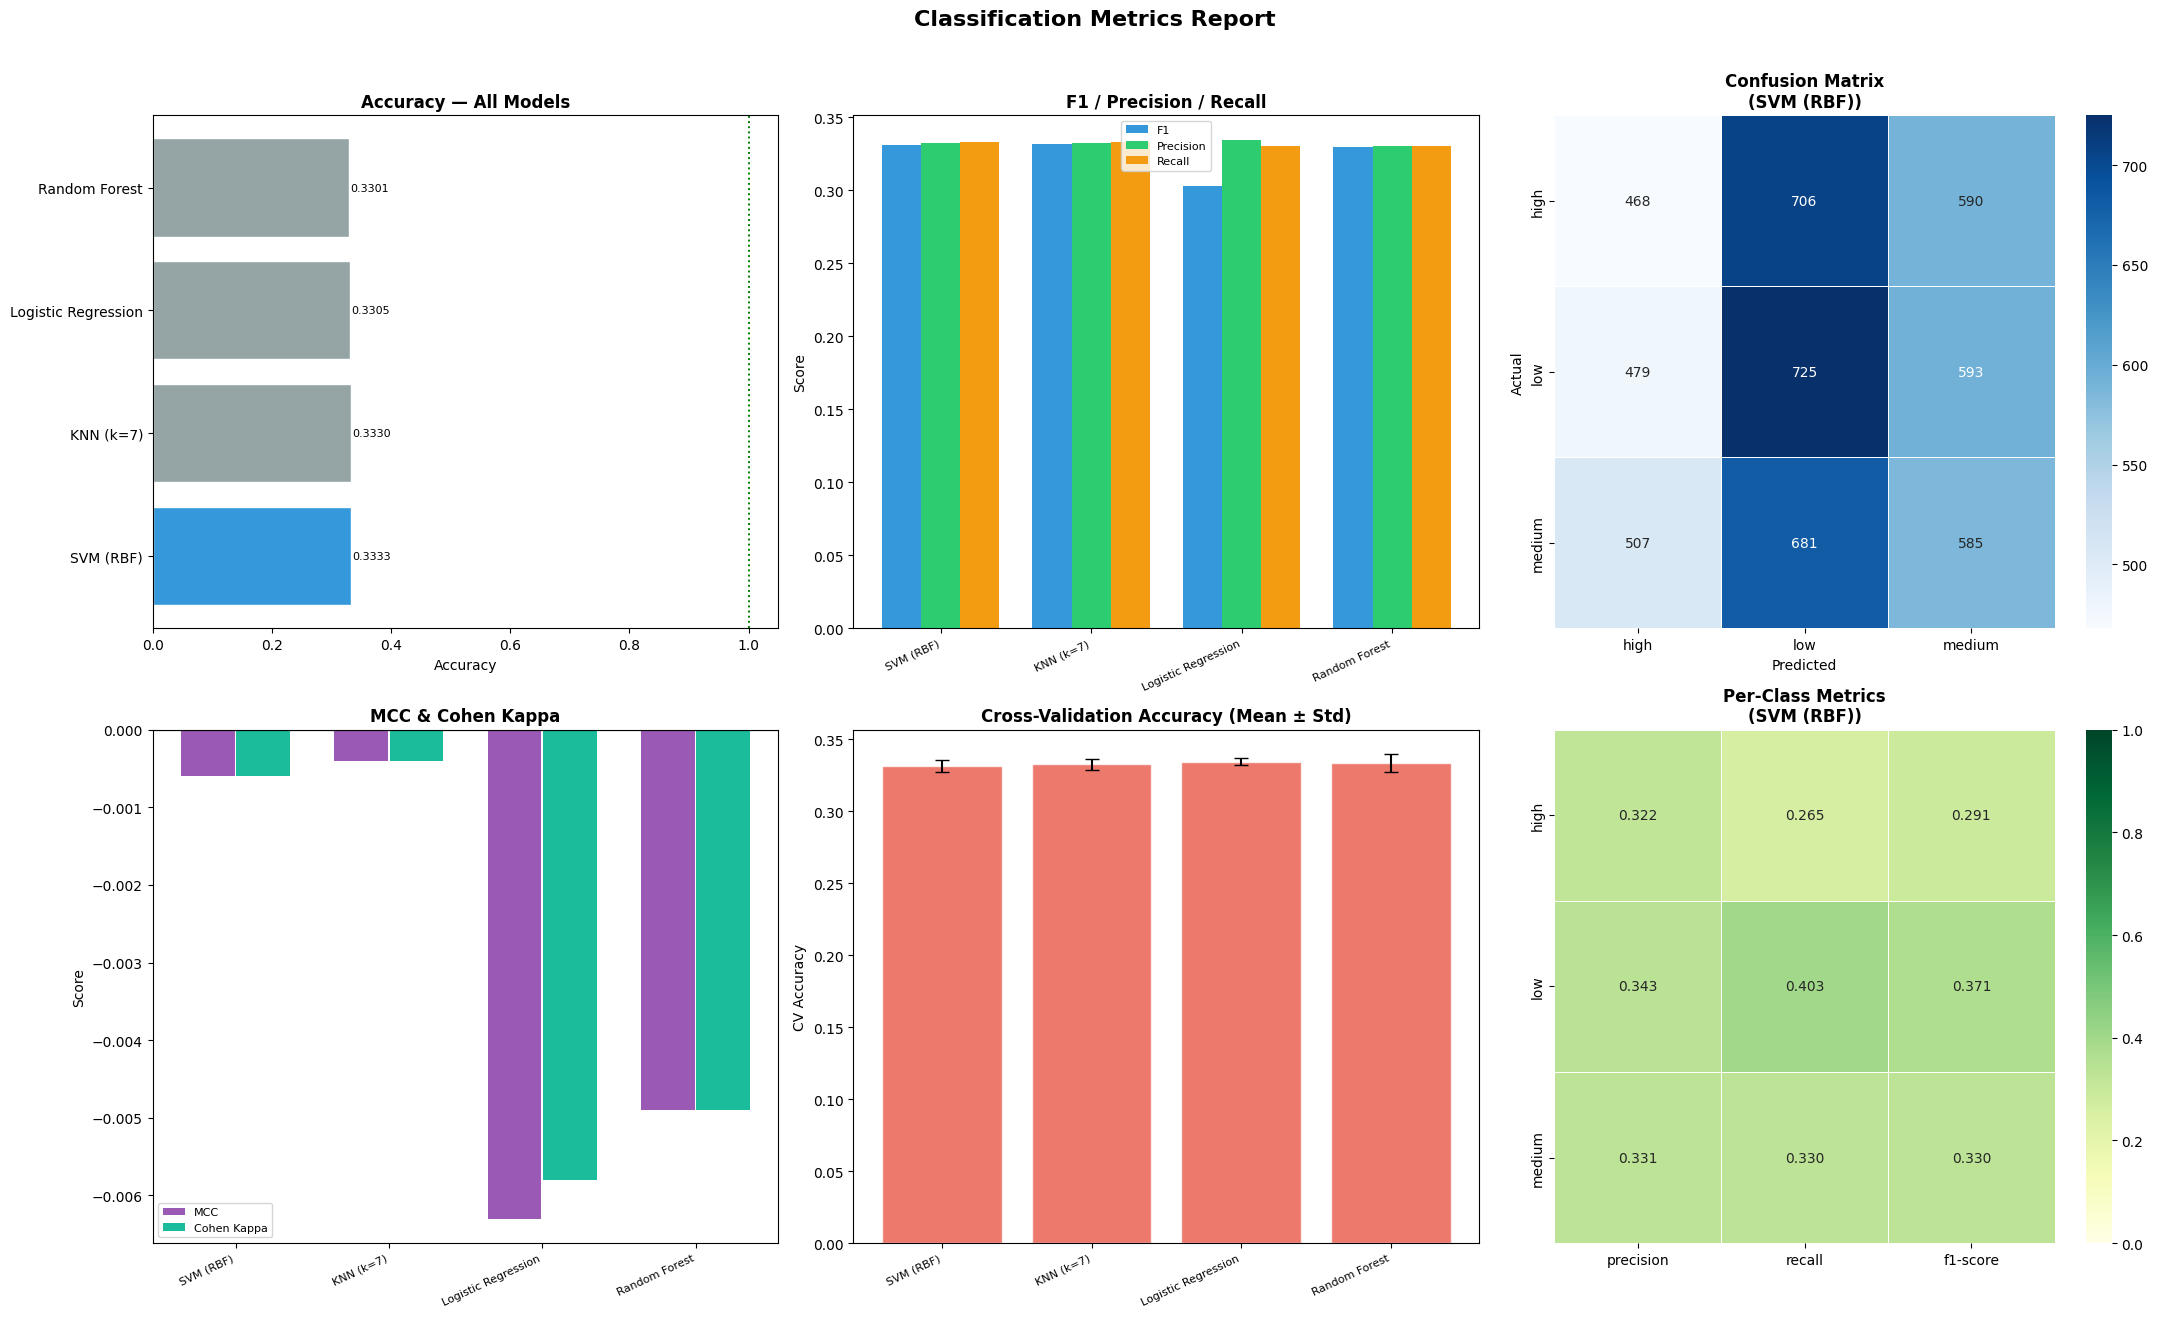

  ✅ Classification metrics plot saved → /content/drive/MyDrive/Intelligent-Cloud-Resource-Optimization-System/reports/stage2_classification_metrics.png

════════════════════════════════════════════════════════════════════════
  CLASSIFICATION MODEL RANKING
════════════════════════════════════════════════════════════════════════
 Rank               Model  Accuracy     F1  Precision  Recall     MCC  CV Mean  CV Std
    1           KNN (k=7)    0.3330 0.3314     0.3324  0.3330 -0.0004   0.3326  0.0038
    2           SVM (RBF)    0.3333 0.3310     0.3321  0.3333 -0.0006   0.3316  0.0042
    3       Random Forest    0.3301 0.3299     0.3301  0.3301 -0.0049   0.3335  0.0062
    4 Logistic Regression    0.3305 0.3030     0.3347  0.3305 -0.0063   0.3346  0.0023


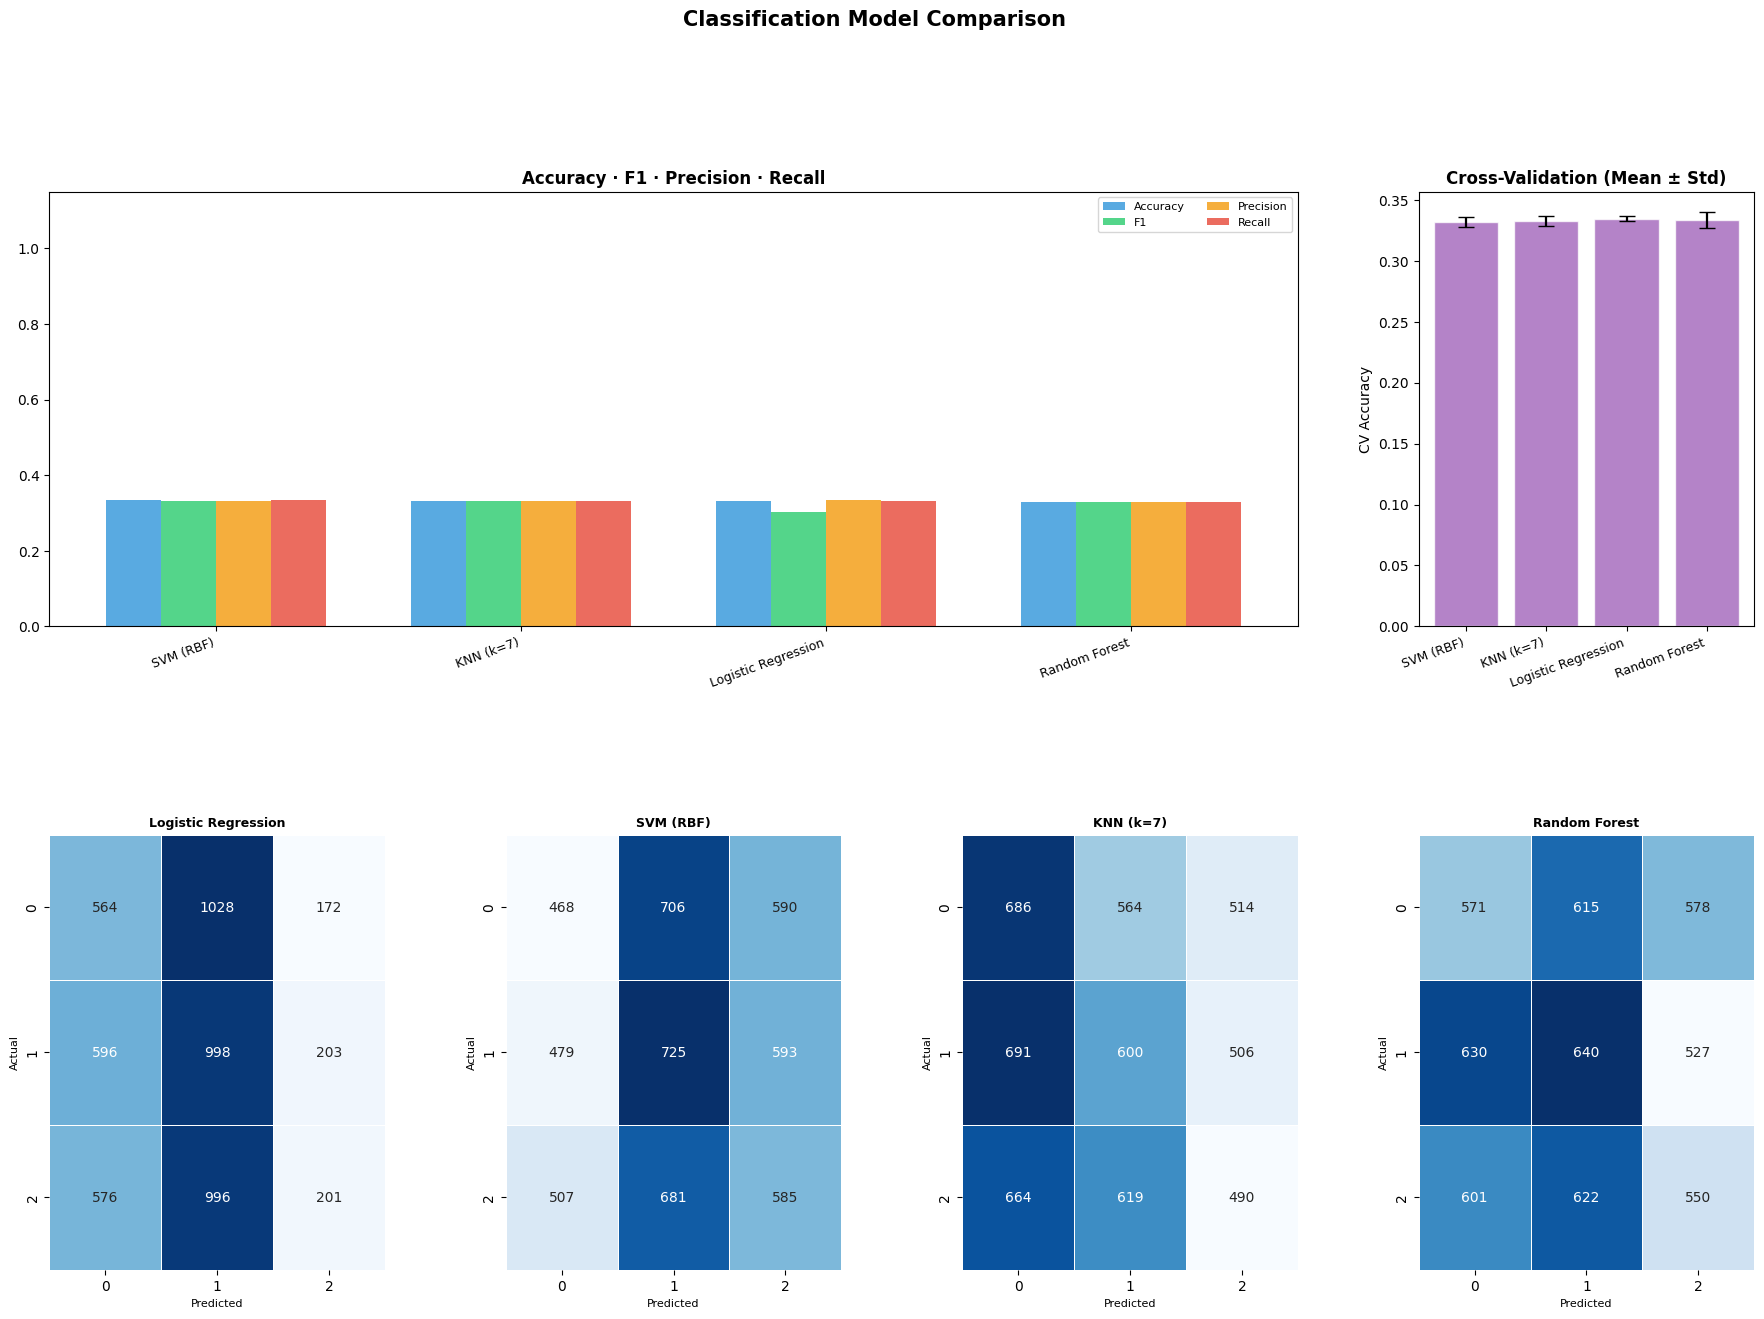

  ✅ Classification comparison saved → /content/drive/MyDrive/Intelligent-Cloud-Resource-Optimization-System/reports/stage2_classification_comparison.png

  Best Classification Model : KNN (k=7)
  Accuracy                  : 0.333
  F1 (weighted)             : 0.3314


In [16]:
# ── 2.B.3 Classification metrics & plots ──────────────────────────────────────
df_clf_summary = clf_rpt.summary()
clf_rpt.plot(save_path=f'{REPORTS_DIR}/stage2_classification_metrics.png')

df_clf_rank = clf_cmp.rank()
clf_cmp.plot(save_path=f'{REPORTS_DIR}/stage2_classification_comparison.png')

best_clf = df_clf_rank.iloc[0]
print(f'\n  Best Classification Model : {best_clf["Model"]}')
print(f'  Accuracy                  : {best_clf["Accuracy"]}')
print(f'  F1 (weighted)             : {best_clf["F1"]}')

---
# 🔵 Stage 3 — Unsupervised Learning (Clustering)

**Goal:** Discover natural workload groups without using labels.  
**Algorithms:** KMeans · DBSCAN · Agglomerative Hierarchical.  
**Evaluation:** Silhouette score · Davies-Bouldin index · Calinski-Harabasz index.


In [ ]:
from sklearn.cluster     import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

print('✅ Clustering imports ready.')

In [ ]:
# ── 3.1 Prepare clustering feature matrix ─────────────────────────────────────
from sklearn.preprocessing import MinMaxScaler

CLUST_FEATURES = ['cpu_usage', 'memory_usage', 'network_traffic',
                   'power_consumption', 'execution_time',
                   'energy_efficiency']

# Check for missing values before dropping them
print("\nMissing values in clustering features before dropping:")
print(df[CLUST_FEATURES].isnull().sum())

df_clust   = df[CLUST_FEATURES].dropna()
scaler_mm  = MinMaxScaler()
X_clust    = scaler_mm.fit_transform(df_clust.values)

print(f'\nClustering matrix shape after dropping NA: {X_clust.shape}')

In [ ]:
# ── 3.2 KMeans — Elbow + Silhouette sweep ─────────────────────────────────────
from sklearn.metrics import silhouette_score

K_RANGE   = range(2, 11)
inertias  = []
sil_scores= []

for k in K_RANGE:
    km  = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    lbl = km.fit_predict(X_clust)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_clust, lbl,
                                        sample_size=3000,
                                        random_state=SEED))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(list(K_RANGE), inertias, 'bo-', linewidth=2.2)
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (WCSS)')
ax1.set_title('Elbow Method', fontweight='bold')

ax2.plot(list(K_RANGE), sil_scores, 'rs-', linewidth=2.2)
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score vs k', fontweight='bold')
ax2.axvline(sil_scores.index(max(sil_scores)) + 2,
             color='green', linestyle='--',
             label=f'Best k={sil_scores.index(max(sil_scores))+2}')
ax2.legend()

plt.suptitle('Stage 3 — KMeans Hyperparameter Selection',
              fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{REPORTS_DIR}/stage3_kmeans_selection.png',
             dpi=150, bbox_inches='tight')
plt.show()

BEST_K = sil_scores.index(max(sil_scores)) + 2
print(f'✅ Best k = {BEST_K}  (Silhouette = {max(sil_scores):.4f})')

In [ ]:
# ── 3.3 Fit all clustering algorithms ─────────────────────────────────────────
from evaluation.metrics_report import ClusteringMetricsReport

clust_rpt = ClusteringMetricsReport()

# KMeans
km_model   = KMeans(n_clusters=BEST_K, random_state=SEED, n_init=10)
labels_km  = km_model.fit_predict(X_clust)
clust_rpt.add_result('KMeans', X_clust, labels_km, n_clusters=BEST_K)

# DBSCAN
db_model   = DBSCAN(eps=0.08, min_samples=5, n_jobs=-1)
labels_db  = db_model.fit_predict(X_clust)
clust_rpt.add_result('DBSCAN', X_clust, labels_db)

# Agglomerative
ag_model   = AgglomerativeClustering(n_clusters=BEST_K,
                                      linkage='ward')
labels_ag  = ag_model.fit_predict(X_clust)
clust_rpt.add_result('Agglomerative', X_clust, labels_ag,
                      n_clusters=BEST_K)

print('✅ All clustering algorithms fitted.')

In [ ]:
# ── 3.4 Clustering metrics & PCA visualisation ────────────────────────────────
df_clust_summary = clust_rpt.summary()
clust_rpt.plot(save_path=f'{REPORTS_DIR}/stage3_clustering_metrics.png')

# PCA 2-D scatter
pca       = PCA(n_components=2, random_state=SEED)
X_pca     = pca.fit_transform(X_clust)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, (title, labels) in zip(
        axes,
        [('KMeans',       labels_km),
         ('DBSCAN',       labels_db),
         ('Agglomerative',labels_ag)]):
    sc = ax.scatter(X_pca[:, 0], X_pca[:, 1],
                     c=labels, cmap='tab10',
                     s=6, alpha=0.5)
    ax.set_title(f'{title}\n({len(set(labels)-{-1})} clusters)',
                  fontweight='bold')
    ax.set_xlabel('PC 1')
    ax.set_ylabel('PC 2')

plt.suptitle('Stage 3 — PCA 2-D Cluster Visualisation',
              fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{REPORTS_DIR}/stage3_pca_clusters.png',
             dpi=150, bbox_inches='tight')
plt.show()

best_clust = df_clust_summary.iloc[0]
print(f'\n  Best Algorithm : {best_clust["Algorithm"]}')
print(f'  Silhouette     : {best_clust["Silhouette"]}')

---
# 📐 Stage 4 — Learning Theory

**Topics covered**
- Bias–Variance trade-off decomposition
- Regularisation paths (Ridge α sweep)
- Learning curves (train size vs error)
- Validation curves (hyperparameter vs error)


In [ ]:
from sklearn.model_selection import learning_curve, validation_curve
from sklearn.pipeline        import Pipeline

print('✅ Learning theory imports ready.')

In [ ]:
# ── 4.1 Bias-Variance decomposition across polynomial degrees ─────────────────
from sklearn.preprocessing   import PolynomialFeatures
from sklearn.linear_model    import LinearRegression
from sklearn.metrics         import mean_squared_error

DEGREES   = range(1, 8)
bv_train  = []
bv_test   = []

for deg in DEGREES:
    pipe = Pipeline([
        ('poly',  PolynomialFeatures(deg, include_bias=False)),
        ('scaler',StandardScaler()),
        ('model', LinearRegression()),
    ])
    pipe.fit(X_reg_tr, y_reg_tr)
    bv_train.append(mean_squared_error(y_reg_tr,
                                        pipe.predict(X_reg_tr)))
    bv_test.append( mean_squared_error(y_reg_te,
                                        pipe.predict(X_reg_te)))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(list(DEGREES), bv_train, 'b-o', linewidth=2.2,
         label='Train MSE  (Bias²)')
ax.plot(list(DEGREES), bv_test,  'r-s', linewidth=2.2,
         label='Test MSE   (Bias² + Variance)')
ax.set_xlabel('Polynomial Degree')
ax.set_ylabel('MSE')
ax.set_title('Stage 4 — Bias–Variance Trade-off',
              fontweight='bold', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig(f'{REPORTS_DIR}/stage4_bias_variance.png',
             dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── 4.2 Learning curves (best regression model) ───────────────────────────────
best_reg_model = reg_models[best_reg['Model']]

train_sz, tr_sc, val_sc = learning_curve(
    best_reg_model,
    X_reg_tr_sc, y_reg_tr,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.fill_between(train_sz,
                 tr_sc.mean(1) - tr_sc.std(1),
                 tr_sc.mean(1) + tr_sc.std(1),
                 alpha=0.12, color='blue')
ax.fill_between(train_sz,
                 val_sc.mean(1) - val_sc.std(1),
                 val_sc.mean(1) + val_sc.std(1),
                 alpha=0.12, color='red')
ax.plot(train_sz, tr_sc.mean(1),  'b-o',
         linewidth=2.2, label='Training R²')
ax.plot(train_sz, val_sc.mean(1), 'r-s',
         linewidth=2.2, label='Validation R²')
ax.set_xlabel('Training Set Size')
ax.set_ylabel('R²')
ax.set_title(f'Stage 4 — Learning Curves ({best_reg["Model"]})',
              fontweight='bold', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig(f'{REPORTS_DIR}/stage4_learning_curves.png',
             dpi=150, bbox_inches='tight')
plt.show()
print('✅ Stage 4 — Learning Theory complete.')

---
# 🎮 Stage 5 — Reinforcement Learning

**Task:** Train an RL agent to schedule cloud resources dynamically.  
**Environment:** Custom `CloudComputingEnv` (6-D state, 4 actions, shaped reward).  
**Agents:** Tabular Q-Learning · Deep Q-Network (DQN) · Random baseline.


In [ ]:
import tensorflow as tf
tf.random.set_seed(SEED)

# Import RL pipeline from Stage 4 script
# (Assumes rl_pipeline.py or inline definitions in this notebook)
# If running as standalone, paste RL classes here or import:
# from rl_pipeline import CloudComputingEnv, QLearningAgent,
#                         DQNAgent, RandomAgent, run_stage4

print(f'✅ TensorFlow {tf.__version__} ready.')

In [ ]:
# ── 5.1 Run full RL pipeline ──────────────────────────────────────────────────
# This single call trains Q-Learning (600 ep), DQN (500 ep),
# evaluates both, and generates the 15-panel dashboard.

rl_results = run_stage4(df)   # defined in Stage 4 script

# Unpack results
env        = rl_results['env']
ql_agent   = rl_results['ql_agent']
dqn_agent  = rl_results['dqn_agent']
ql_log     = rl_results['ql_log']
dqn_log    = rl_results['dqn_log']
ql_eval    = rl_results['ql_eval']
dqn_eval   = rl_results['dqn_eval']
rand_eval  = rl_results['rand_eval']

print('\n✅ Stage 5 — Reinforcement Learning complete.')

In [ ]:
# ── 5.2 RL metrics report ─────────────────────────────────────────────────────
rl_rpt = RLMetricsReport(
    action_names=list(env.ACTION_NAMES.values()))

rl_rpt.add_agent('Q-Learning', ql_log,  ql_eval)
rl_rpt.add_agent('DQN',        dqn_log, dqn_eval)
rl_rpt.add_agent('Random',     None,    rand_eval)

df_rl_summary = rl_rpt.summary()
rl_rpt.plot(save_path=f'{REPORTS_DIR}/stage5_rl_metrics.png')

best_rl = df_rl_summary.sort_values(
    'Eval Mean Reward', ascending=False).iloc[0]
print(f'\n  Best RL Agent  : {best_rl["Agent"]}')
print(f'  Eval Reward    : {best_rl["Eval Mean Reward"]}')
print(f'  SLA Violation  : {best_rl["SLA Violation %"]}%')

---
# 🏆 Stage 6 — Final Dashboard & Master Report

Consolidates the best result from every stage into:
- A **cross-stage leaderboard** table
- A **master JSON report** for reproducibility
- A **visual summary dashboard** saved as PNG


In [ ]:
# ── 6.1 Build cross-stage leaderboard ─────────────────────────────────────────
lb = CrossStageLeaderboard()

lb.add_stage(
    stage_name = 'Regression',
    best_model = str(best_reg['Model']),
    metrics    = {'R²':   float(best_reg['Test R²']),
                  'RMSE': float(best_reg['RMSE'])},
)

lb.add_stage(
    stage_name = 'Classification',
    best_model = str(best_clf['Model']),
    metrics    = {'Accuracy': float(best_clf['Accuracy']),
                  'F1':       float(best_clf['F1'])},
)

lb.add_stage(
    stage_name = 'Clustering',
    best_model = str(best_clust['Algorithm']),
    metrics    = {'Silhouette': float(best_clust['Silhouette']),
                  'DB Index':   float(best_clust['Davies-Bouldin'])},
)

lb.add_stage(
    stage_name = 'Learning Theory',
    best_model = 'Bias-Variance Analysis',
    metrics    = {'Min Test MSE': float(min(bv_test)),
                  'Optimal Degree': int(
                      list(DEGREES)[bv_test.index(min(bv_test))])},
)

lb.add_stage(
    stage_name = 'RL (DQN)',
    best_model = str(best_rl['Agent']),
    metrics    = {'Eval Reward': float(best_rl['Eval Mean Reward']),
                  'SLA Viol %': float(best_rl['SLA Violation %'])},
)

df_leaderboard = lb.table()
lb.plot(save_path=f'{REPORTS_DIR}/stage6_leaderboard.png')

print('\n✅ Cross-stage leaderboard complete.')

In [ ]:
# ── 6.2 Generate master JSON report ───────────────────────────────────────────
master = generate_master_report(
    reg_report   = reg_rpt,
    clf_report   = clf_rpt,
    clust_report = clust_rpt,
    rl_report    = rl_rpt,
    project_name = 'Cloud Resource Optimisation — ML Capstone',
    output_path  = f'{REPORTS_DIR}/master_metrics_report.json',
)

print('\n✅ Master report saved.')

In [ ]:
# ── 6.3 Print artefact manifest ───────────────────────────────────────────────
import glob

artefacts = sorted(glob.glob(f'{REPORTS_DIR}/**/*', recursive=True))

print('\n' + '═' * 60)
print('  CAPSTONE ARTEFACT MANIFEST')
print('═' * 60)
for f in artefacts:
    size_kb = os.path.getsize(f) / 1024
    print(f'  {f:<55}  {size_kb:>7.1f} KB')

print('\n' + '═' * 60)
print('  ✅ ALL STAGES COMPLETE — Capstone Project Finished!')
print('═' * 60)